## 混合图神经网络 (Hybrid GNN) - 图表征 + 分子描述符
这个模型将会读取 `hybrid_gnn_data.pkl`，通过 GCN (图卷积神经网络) 提取分子的空间拓扑特征，然后和提取的 10 个重要的化学/物理描述符（如 LogP 等）拼接，最后由 MLP (多层感知机) 完成水溶性的回归预测。

In [1]:
import torch
import pickle
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data, Dataset
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, global_mean_pool
import matplotlib.pyplot as plt
import numpy as np

c:\Anaconda\envs\pytorch\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# 1. 整理读取 Dataset 并将其转为 PyG 标准的 Data 格式 
class HybridESOLDataset(Dataset):
    def __init__(self, pickle_file):
        super().__init__()
        with open(pickle_file, 'rb') as f:
            self.data_list = pickle.load(f)
            
    def len(self):
        return len(self.data_list)
        
    def get(self, idx):
        item = self.data_list[idx]
        # 节点特征：每个分子不同的原子特征
        x = torch.tensor(item['x'], dtype=torch.float)
        
        # 图的边连接：邻接矩阵 (一定要转置为 2 x E 的形状)
        edge_index = torch.tensor(item['edge_index'], dtype=torch.long)
        if edge_index.numel() > 0:
            edge_index = edge_index.t().contiguous()
        else:
            edge_index = torch.empty((2,0), dtype=torch.long)
            
        # 真实标签 target 和描述符 descriptor 
        y = torch.tensor([item['y']], dtype=torch.float)
        descriptors = torch.tensor([item['descriptors']], dtype=torch.float)
        
        return Data(x=x, edge_index=edge_index, y=y, descriptors=descriptors)

dataset = HybridESOLDataset('data/hybrid_gnn_data.pkl')
train_size = int(len(dataset) * 0.8)
test_size = len(dataset) - train_size

# 划分数据集并构建 Loader (自动将图数据打包)
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [3]:
# 2. 构建混合 GNN + MLP 架构
class HybridGNN(nn.Module):
    def __init__(self, node_feature_dim=3, descriptor_dim=10, gnn_hidden_dim=64, mlp_hidden_dim=128):
        super(HybridGNN, self).__init__()
        # --- GNN部分 --- 3 -> 64 -> 64
        self.conv1 = GCNConv(node_feature_dim, gnn_hidden_dim)
        self.bn_gnn1 = nn.BatchNorm1d(gnn_hidden_dim)

        self.conv2 = GCNConv(gnn_hidden_dim, gnn_hidden_dim)
        self.bn_gnn2 = nn.BatchNorm1d(gnn_hidden_dim)

        self.conv3 = GCNConv(gnn_hidden_dim, gnn_hidden_dim)
        self.bn_gnn3 = nn.BatchNorm1d(gnn_hidden_dim)
        
        # --- 与物理描述符融合  --- 64 + 10
        combined_dim = gnn_hidden_dim + descriptor_dim
        
        #--- MLP部分 --- 64 + 10 -> 128 -> 64 -> 1
        self.fc1 = nn.Linear(combined_dim, mlp_hidden_dim)
        self.bn_fc1 = nn.BatchNorm1d(mlp_hidden_dim)

        self.fc2 = nn.Linear(mlp_hidden_dim, mlp_hidden_dim // 2)
        self.bn_fc2 = nn.BatchNorm1d(mlp_hidden_dim // 2)

        self.out = nn.Linear(mlp_hidden_dim // 2, 1)
        self.dropout = nn.Dropout(0.1)

    def forward(self, data):
        x, edge_index, batch, descriptors = data.x, data.edge_index, data.batch, data.descriptors

        gnn_x = self.conv1(x, edge_index)
        gnn_x = self.bn_gnn1(gnn_x)
        gnn_x = F.relu(gnn_x)
        
        gnn_x = self.conv2(gnn_x, edge_index)
        gnn_x = self.bn_gnn2(gnn_x)
        gnn_x = F.relu(gnn_x)

        gnn_x = self.conv3(gnn_x, edge_index)
        gnn_x = self.bn_gnn3(gnn_x)
        gnn_x = F.relu(gnn_x)
        
        graph_embedding = global_mean_pool(gnn_x, batch)
        
        #特征拼接：64+10
        combined = torch.cat([graph_embedding, descriptors.view(graph_embedding.size(0), -1)], dim=1)
        
        out = self.fc1(combined)
        out = self.bn_fc1(out)
        out = F.relu(out)
        out = self.dropout(out)
        
        out = self.fc2(out)
        out = self.bn_fc2(out)
        out = F.relu(out)
        out = self.dropout(out)
        
        return self.out(out)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"当前使用的设备: {device}")

model = HybridGNN().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

当前使用的设备: cuda


In [4]:
# 3. 训练与验证
def train():
    model.train()
    total_loss = 0
    for data in train_loader:
        data = data.to(device)
        optimizer.zero_grad()
        
        out = model(data)
        loss = criterion(out.view(-1), data.y.view(-1))
        loss.backward()
        
        optimizer.step()
        total_loss += loss.item() * data.num_graphs
    
    return total_loss / len(train_loader.dataset)

def test(loader):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            out = model(data)
            loss = criterion(out.view(-1), data.y.view(-1))
            
            total_loss += loss.item() * data.num_graphs
    
    return total_loss / len(loader.dataset)

for epoch in range(1, 1001):
    loss = train()
    test_loss = test(test_loader)
    if epoch % 10 == 0:
        print(f'Epoch: {epoch}, Train Loss: {loss:.4f}, Test Loss: {test_loss:.4f}')

Epoch: 10, Train Loss: 0.9748, Test Loss: 1.2706
Epoch: 20, Train Loss: 0.8083, Test Loss: 1.0043
Epoch: 30, Train Loss: 0.6776, Test Loss: 0.6962
Epoch: 40, Train Loss: 0.7303, Test Loss: 0.6079
Epoch: 50, Train Loss: 0.6646, Test Loss: 0.7220
Epoch: 60, Train Loss: 0.6374, Test Loss: 0.8266
Epoch: 70, Train Loss: 0.5302, Test Loss: 0.6485
Epoch: 80, Train Loss: 0.5264, Test Loss: 0.7516
Epoch: 90, Train Loss: 0.5083, Test Loss: 0.5416
Epoch: 100, Train Loss: 0.5390, Test Loss: 0.5582
Epoch: 110, Train Loss: 0.5858, Test Loss: 0.4499
Epoch: 120, Train Loss: 0.5181, Test Loss: 0.4719
Epoch: 130, Train Loss: 0.4812, Test Loss: 0.4796
Epoch: 140, Train Loss: 0.4536, Test Loss: 0.4961
Epoch: 150, Train Loss: 0.5044, Test Loss: 0.5771
Epoch: 160, Train Loss: 0.4586, Test Loss: 0.5213
Epoch: 170, Train Loss: 0.4236, Test Loss: 0.5300
Epoch: 180, Train Loss: 0.4930, Test Loss: 0.6093
Epoch: 190, Train Loss: 0.4544, Test Loss: 0.4777
Epoch: 200, Train Loss: 0.4170, Test Loss: 0.5198
Epoch: 21

In [5]:
# 收集所有测试集的预测值和真实值
model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for data in test_loader:
        data = data.to(device)
        out = model(data)
        all_preds.append(out.view(-1).cpu())
        all_targets.append(data.y.view(-1).cpu())

# 转换为一维 numpy 数组
all_preds = torch.cat(all_preds).numpy()
all_targets = torch.cat(all_targets).numpy()

# 计算 RMSE 和 MAE
rmse = np.sqrt(np.mean((all_preds - all_targets) ** 2))
mae = np.mean(np.abs(all_preds - all_targets))

print(f"Test RMSE: {rmse:.4f}")
print(f"Test MAE: {mae:.4f}")

Test RMSE: 0.6170
Test MAE: 0.4694


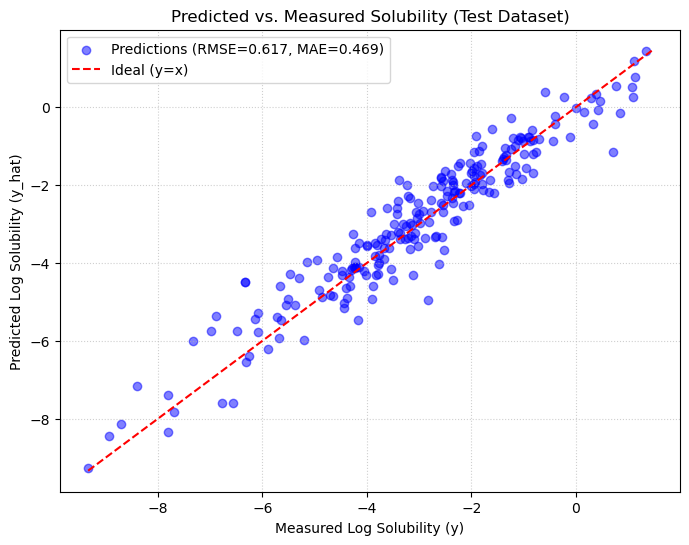

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

# 画散点图
plt.scatter(all_targets, all_preds, alpha=0.5, color='blue', label=f'Predictions (RMSE={rmse:.3f}, MAE={mae:.3f})')

# 画 45 度理想线
min_val = min(all_targets.min(), all_preds.min())
max_val = max(all_targets.max(), all_preds.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Ideal (y=x)')

plt.xlabel('Measured Log Solubility (y)')
plt.ylabel('Predicted Log Solubility (y_hat)')
plt.title('Predicted vs. Measured Solubility (Test Dataset)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()